# Executive Summary

This project analyzes over 500,000 retail transactions to understand customer behavior, sales performance and revenue drivers.

Key findings:

- UK generated majority of revenue
- Sales peaked during Q4
- Revenue distribution was highly skewed
- 609 Champion customers identified through RFM analysis
- Home décor and gift products dominated sales volume

#Load Data

In [1]:
#Import Library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_excel(
    "/content/drive/MyDrive/Online Retail.xlsx"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


np.int64(5268)

#Preprocessing

In [5]:
df = df.drop_duplicates()

In [6]:
df = df.dropna(subset=['CustomerID'])

In [7]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [8]:
df = df[df['Quantity'] > 0]

In [9]:
df = df[df['UnitPrice'] > 0]

In [10]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
df.shape

(392692, 9)

The dataset contained duplicate transactions,
missing customer identifiers and cancelled orders.

The following preprocessing steps were performed:
- Removed duplicates
- Removed cancelled invoices
- Removed invalid quantities
- Removed missing customer IDs

#EDA

## Revenue Analysis

In [12]:
#Understand Revenue Distribution
df['Revenue'].describe()

,Revenue
count,392692.000000
mean,22.631500
std,311.099224
min,0.001000
25%,4.950000
50%,12.450000
75%,19.800000
max,168469.600000


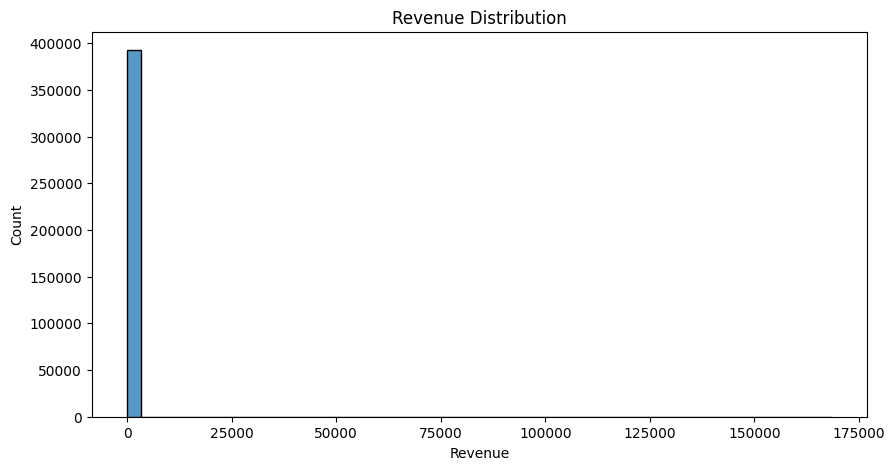

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df['Revenue'], bins=50)

plt.title('Revenue Distribution')

plt.show()

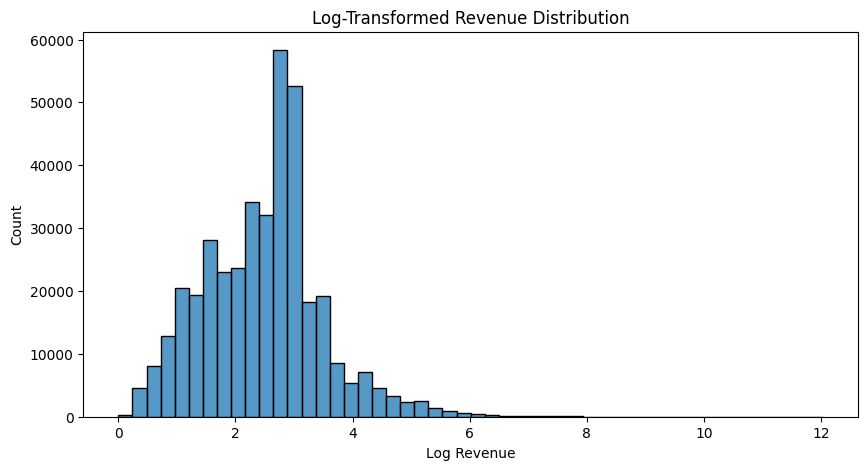

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(df['Revenue']), bins=50)

plt.title('Log-Transformed Revenue Distribution')

plt.xlabel('Log Revenue')

plt.show()

### Observation

Revenue distribution is highly right-skewed, with most transactions contributing relatively small revenue amounts and a small number of transactions generating exceptionally high revenue. A log transformation was applied to improve interpretability.

average transaction value,
max revenue,
distribution spread,
possible outliers




In [15]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

country_sales.head(10)

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


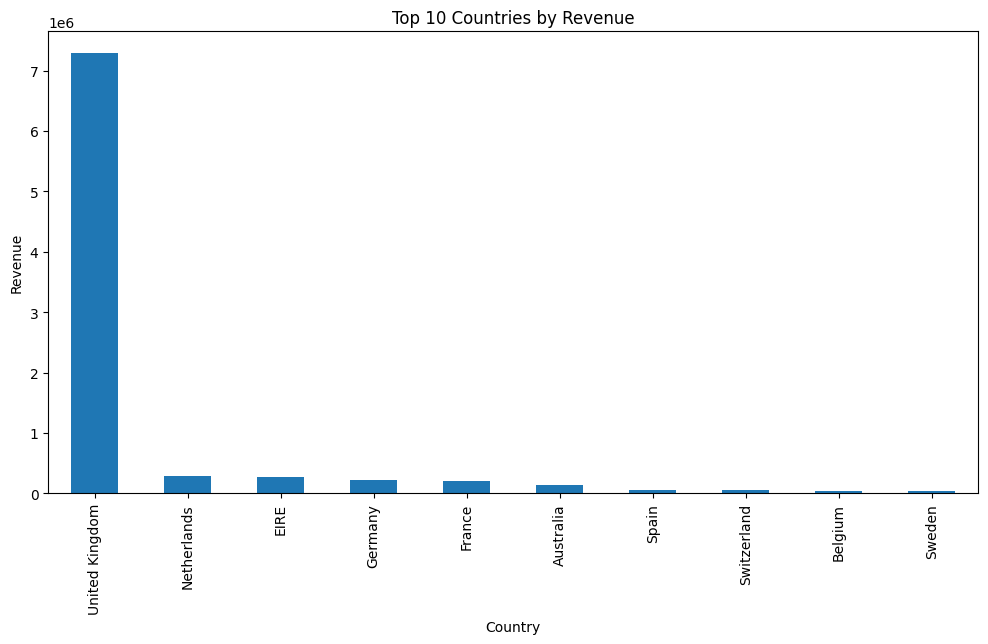

In [16]:
top_countries = country_sales.head(10)

plt.figure(figsize=(12,6))
top_countries.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.show()

### Observation

The United Kingdom generated significantly more revenue than any other market.

The Netherlands, EIRE, Germany and France emerged as the strongest secondary markets.

This suggests the retailer's customer base is primarily domestic while maintaining a strong European presence.

Monthly Revenue Trend

In [17]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

In [18]:
monthly_sales = df.groupby('YearMonth')['Revenue'].sum()

monthly_sales.head()

,Revenue
YearMonth,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331


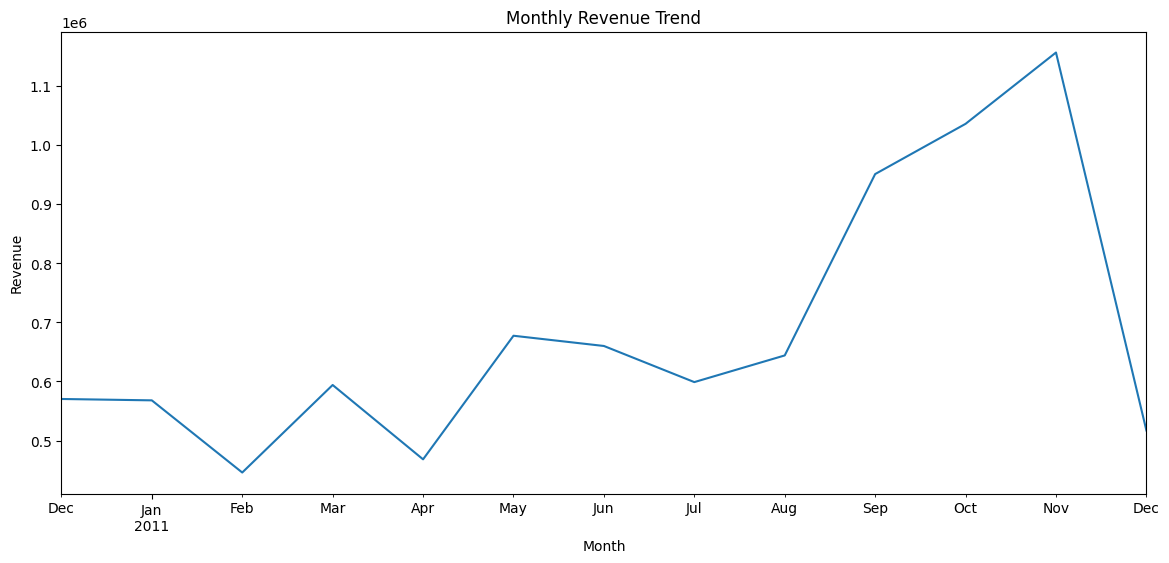

In [19]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

### Observation

Revenue increased steadily throughout the year and peaked during November. This suggests strong seasonal demand and holiday purchasing behavior during Q4.

## Product Analysis

In [20]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

top_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


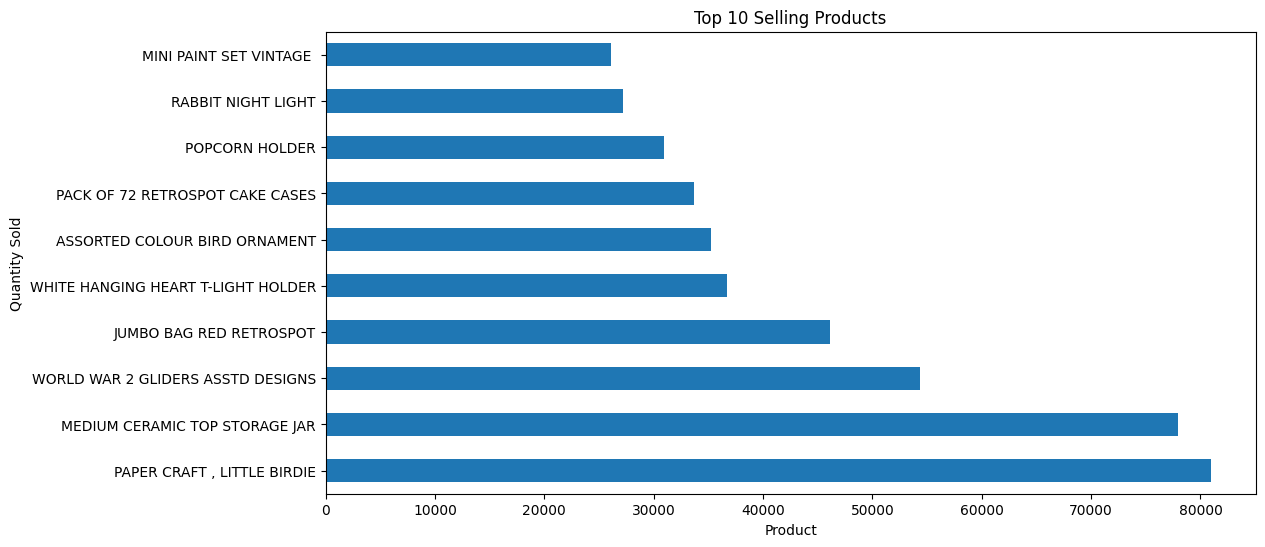

In [21]:
plt.figure(figsize=(12,6))

top_products.head(10).plot(kind='barh')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.show()

### Observation

Home décor and gift-related products dominated sales volume. The popularity of these products suggests that the retailer operates within a lifestyle and gifting market segment.

Customer Analysis

In [22]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

top_customers.head(10)

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


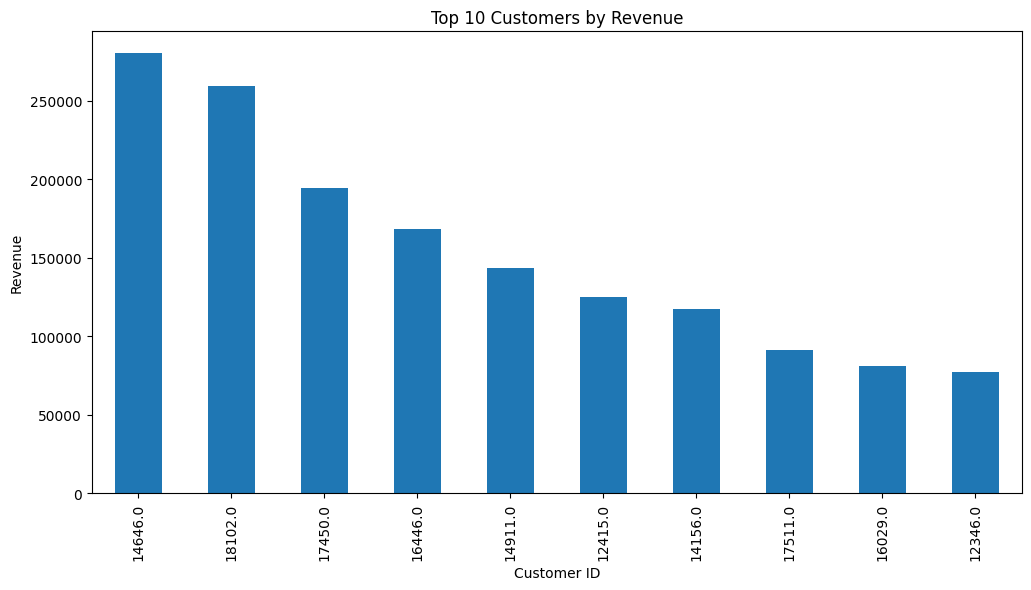

In [23]:
plt.figure(figsize=(12,6))

top_customers.head(10).plot(kind='bar')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.show()

### Observation

A small number of customers generated significantly higher revenue than the average customer, indicating the presence of high-value customers who contribute disproportionately to overall business performance.

RFM Analysis

In [24]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [25]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [26]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


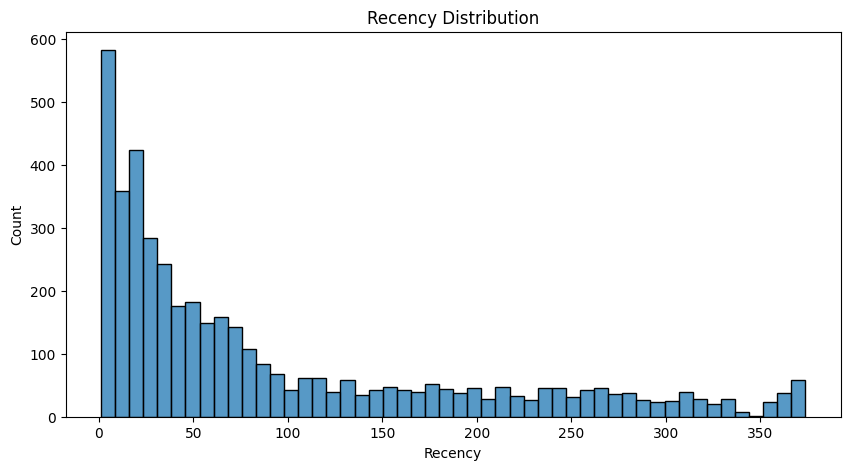

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Recency'], bins=50)

plt.title('Recency Distribution')

plt.show()

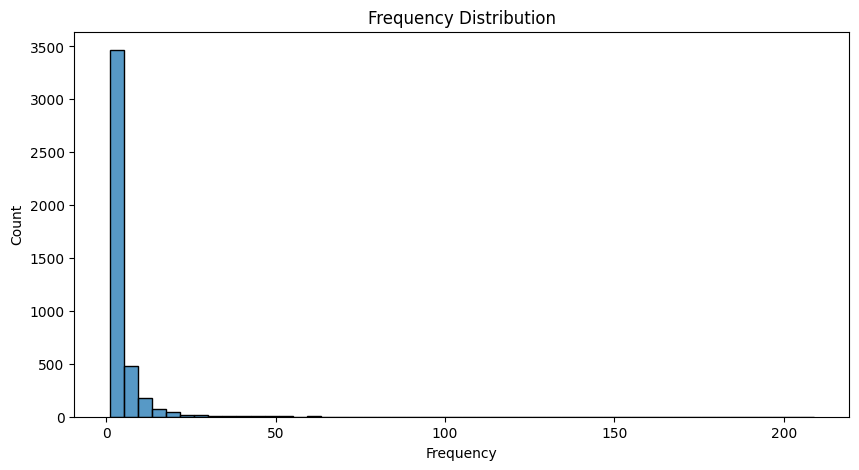

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(rfm['Frequency'], bins=50)

plt.title('Frequency Distribution')

plt.show()

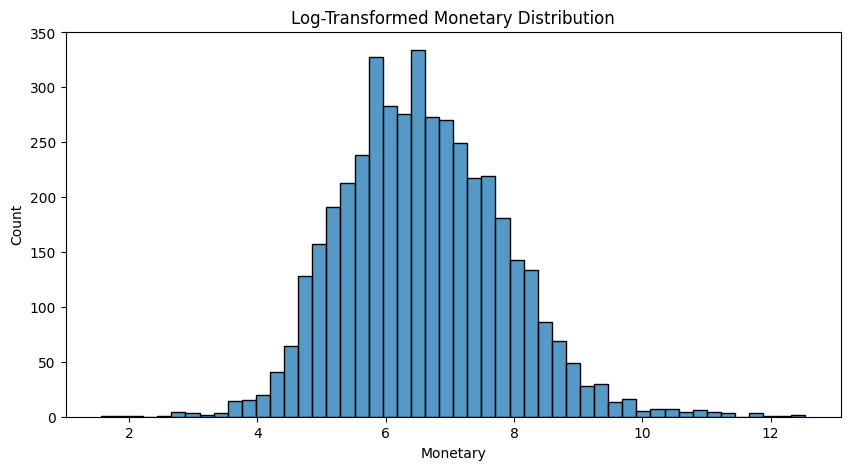

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(rfm['Monetary']), bins=50)

plt.title('Log-Transformed Monetary Distribution')

plt.show()

In [30]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [31]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

In [32]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [33]:
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] == 4:
        return 'Recent Customers'
    elif row['F_score'] == 4:
        return 'Frequent Customers'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Others
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,Others
12349.0,19,1,1757.55,3,1,4,314,Others
12350.0,310,1,334.40,1,1,2,112,Others


In [34]:
rfm['Segment'].value_counts()

,count
Segment,
Others,2407
Loyal Customers,914
Champions,609
Recent Customers,234
Frequent Customers,174


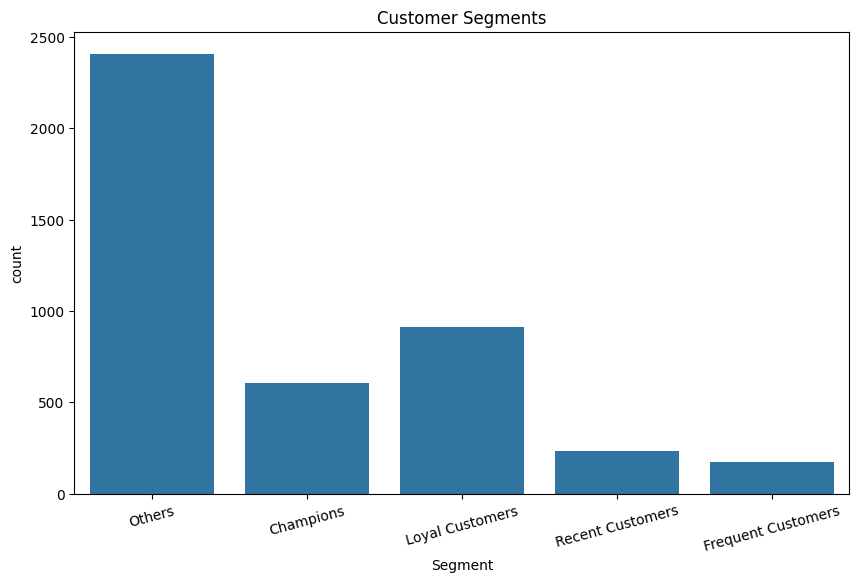

In [35]:
plt.figure(figsize=(10,6))

sns.countplot(data=rfm, x='Segment')

plt.title('Customer Segments')

plt.xticks(rotation=15)

plt.show()

### Observation

RFM analysis identified 609 Champion customers and 914 Loyal customers. These groups represent highly engaged customers who purchase frequently and contribute significant revenue.

In [38]:
total_revenue = df['Revenue'].sum()

total_revenue

np.float64(8887208.894)

In [39]:
total_customers = df['CustomerID'].nunique()

total_customers

4338

In [40]:
total_orders = df['InvoiceNo'].nunique()

total_orders

18532

In [ ]:
average_order_value = df.groupby('InvoiceNo')['Revenue'].sum().mean()

average_order_value

np.float64(479.56016047917126)

In [41]:
df.to_csv('cleaned_retail_data.csv', index=False)

rfm.to_csv('rfm_customer_segments.csv')

## Business KPI Summary
| KPI                 |   Value |
| ------------------- | ------: |
| Total Revenue       |  £8.89M |
| Total Customers     |   4,338 |
| Total Orders        |  18,532 |
| Average Order Value | £479.56 |


# Conclusion

This analysis transformed over 500,000 raw retail transactions into actionable business insights through data cleaning, exploratory analysis, and customer segmentation.

Key findings include:

- The United Kingdom generated the majority of total revenue.
- Revenue peaked during Q4, particularly in November.
- Revenue distribution was highly right-skewed due to a small number of high-value transactions.
- Home décor and gift-oriented products dominated sales volume.
- RFM analysis identified valuable Champion and Loyal customer segments.

These findings can support marketing, customer retention, and sales strategy decisions while demonstrating practical business analytics skills.